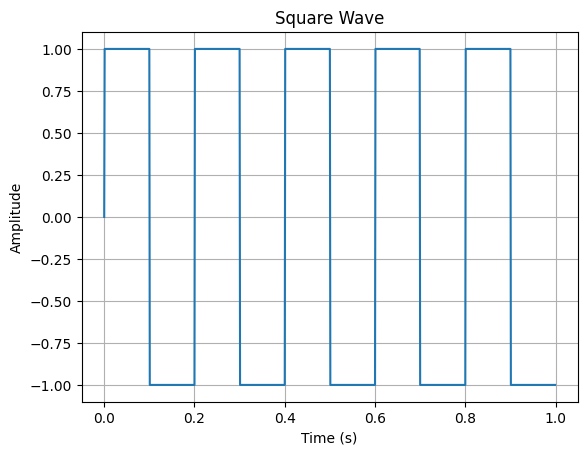

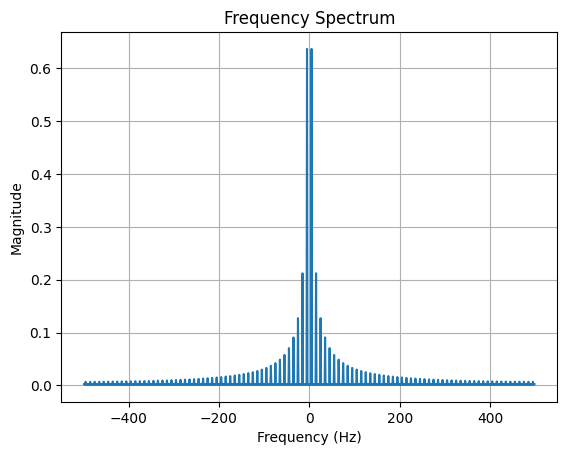

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def square_wave(frequency, duration, sampling_rate):
    t = np.arange(0, duration, 1/sampling_rate)
    signal = np.sign(np.sin(2 * np.pi * frequency * t))
    return t, signal

def plot_spectrum(signal, sampling_rate):
    n = len(signal)
    spectrum = np.fft.fft(signal) / n
    frequencies = np.fft.fftfreq(n, 1/sampling_rate)
    
    # 仅绘制正频率部分
    positive_frequencies = frequencies[:n//2]
    magnitude_spectrum = np.abs(spectrum)[:n//2]
    
    # 将频谱镜像对称
    mirrored_spectrum = np.concatenate((magnitude_spectrum, magnitude_spectrum[::-1]))
    mirrored_frequencies = np.concatenate((positive_frequencies, -positive_frequencies[::-1]))
    
    # 绘制频谱图
    plt.plot(mirrored_frequencies, mirrored_spectrum)
    plt.title('Frequency Spectrum')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.show()

# 设置方波的频率、时长和采样率
frequency = 5  # 频率为5 Hz
duration = 1   # 时长为1秒
sampling_rate = 1000  # 采样率为1000 Hz

# 生成方波信号
t, square_wave_signal = square_wave(frequency, duration, sampling_rate)

# 绘制方波图形
plt.plot(t, square_wave_signal)
plt.title('Square Wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# 绘制方波的频谱图
plot_spectrum(square_wave_signal, sampling_rate)

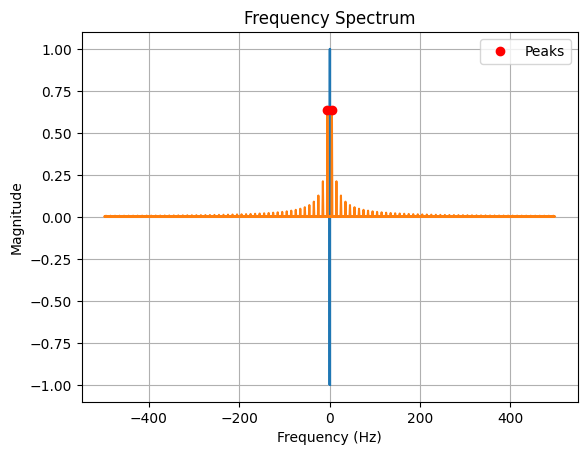

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def square_wave(frequency, duration, sampling_rate):
    t = np.arange(0, duration, 1/sampling_rate)
    signal = np.sign(np.sin(2 * np.pi * frequency * t))
    return t, signal

def plot_spectrum(signal, sampling_rate):
    n = len(signal)
    spectrum = np.fft.fft(signal) / n
    frequencies = np.fft.fftfreq(n, 1/sampling_rate)
    
    # 仅绘制正频率部分
    positive_frequencies = frequencies[:n//2]
    magnitude_spectrum = np.abs(spectrum)[:n//2]
    
    # 将频谱镜像对称
    mirrored_spectrum = np.concatenate((magnitude_spectrum, magnitude_spectrum[::-1]))
    mirrored_frequencies = np.concatenate((positive_frequencies, -positive_frequencies[::-1]))
    
    # 绘制频谱图
    plt.plot(mirrored_frequencies, mirrored_spectrum)
    plt.title('Frequency Spectrum')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    
    return mirrored_frequencies, mirrored_spectrum

# 设置方波的频率、时长和采样率
frequency = 5  # 频率为5 Hz
duration = 1   # 时长为1秒
sampling_rate = 1000  # 采样率为1000 Hz

# 生成方波信号
t, square_wave_signal = square_wave(frequency, duration, sampling_rate)

# 绘制方波图形
plt.figure()
plt.plot(t, square_wave_signal)
plt.title('Square Wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# 绘制方波的频谱图，并获取频率和幅度数据
frequencies, spectrum = plot_spectrum(square_wave_signal, sampling_rate)

# 寻找谱峰
peaks, _ = find_peaks(spectrum, height=0.5)  # 调整height参数以匹配实际情况

# 绘制谱峰
plt.plot(frequencies[peaks], spectrum[peaks], 'ro', label='Peaks')
plt.legend()

# 显示图形
plt.show()

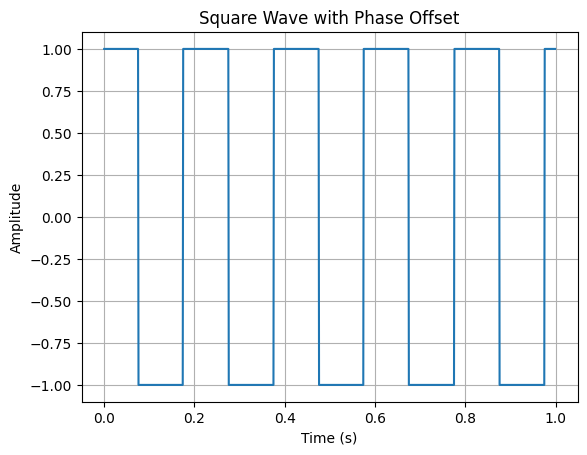

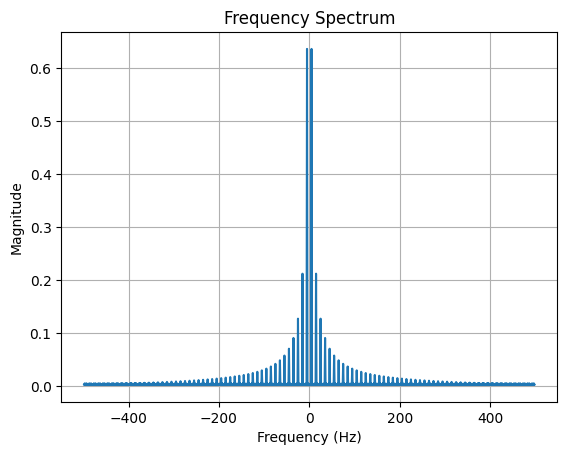

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def square_wave(frequency, duration, sampling_rate, phase_offset=0):
    t = np.arange(0, duration, 1/sampling_rate)
    signal = np.sign(np.sin(2 * np.pi * frequency * t + phase_offset))
    return t, signal

def plot_spectrum(signal, sampling_rate):
    n = len(signal)
    spectrum = np.fft.fft(signal) / n
    frequencies = np.fft.fftfreq(n, 1/sampling_rate)
    
    # 仅绘制正频率部分
    positive_frequencies = frequencies[:n//2]
    magnitude_spectrum = np.abs(spectrum)[:n//2]
    
    # 将频谱镜像对称
    mirrored_spectrum = np.concatenate((magnitude_spectrum, magnitude_spectrum[::-1]))
    mirrored_frequencies = np.concatenate((positive_frequencies, -positive_frequencies[::-1]))
    
    # 绘制频谱图
    plt.plot(mirrored_frequencies, mirrored_spectrum)
    plt.title('Frequency Spectrum')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.show()

# 设置方波的频率、时长和采样率
frequency = 5  # 频率为5 Hz
duration = 1   # 时长为1秒
sampling_rate = 1000  # 采样率为1000 Hz
phase_offset = np.pi/4  # 相位偏移为π/4

# 生成相位移动后的方波信号
t, square_wave_signal = square_wave(frequency, duration, sampling_rate, phase_offset)

# 绘制相位移动后的方波图形
plt.plot(t, square_wave_signal)
plt.title('Square Wave with Phase Offset')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# 绘制相位移动后的方波的频谱图
plot_spectrum(square_wave_signal, sampling_rate)

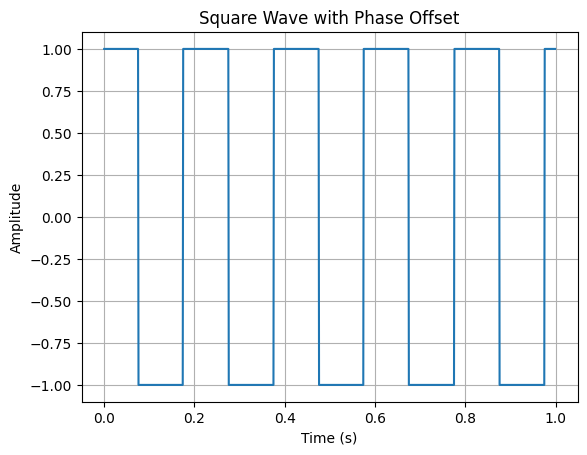

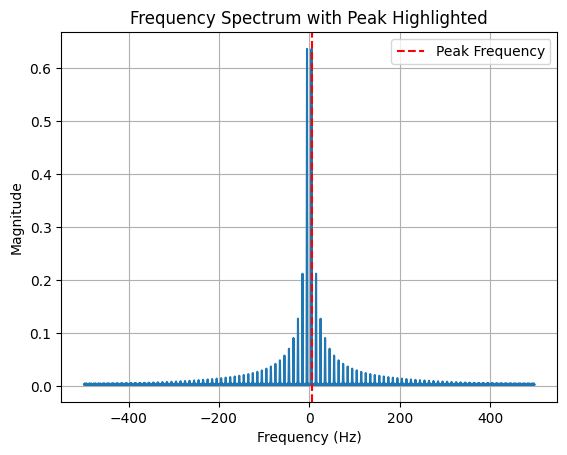

Peak frequency after phase offset: 5.0 Hz


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def square_wave(frequency, duration, sampling_rate, phase_offset=0):
    t = np.arange(0, duration, 1/sampling_rate)
    signal = np.sign(np.sin(2 * np.pi * frequency * t + phase_offset))
    return t, signal

def find_peak_frequency(signal, sampling_rate):
    n = len(signal)
    spectrum = np.fft.fft(signal) / n
    frequencies = np.fft.fftfreq(n, 1/sampling_rate)
    
    # 仅绘制正频率部分
    positive_frequencies = frequencies[:n//2]
    magnitude_spectrum = np.abs(spectrum)[:n//2]
    
    # 将频谱镜像对称
    mirrored_spectrum = np.concatenate((magnitude_spectrum, magnitude_spectrum[::-1]))
    mirrored_frequencies = np.concatenate((positive_frequencies, -positive_frequencies[::-1]))
    
    # 找到谱峰的索引
    peak_index = np.argmax(mirrored_spectrum)
    
    # 获取对应的频率
    peak_frequency = mirrored_frequencies[peak_index]
    
    return peak_frequency, mirrored_frequencies, mirrored_spectrum

# 设置方波的频率、时长和采样率
frequency = 5  # 频率为5 Hz
duration = 1   # 时长为1秒
sampling_rate = 1000  # 采样率为1000 Hz
phase_offset = np.pi/4  # 相位偏移为π/4

# 生成相位移动后的方波信号
t, square_wave_signal = square_wave(frequency, duration, sampling_rate, phase_offset)

# 绘制相位移动后的方波图形
plt.plot(t, square_wave_signal)
plt.title('Square Wave with Phase Offset')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# 绘制相位移动后的方波的频谱图
peak_frequency, frequencies, magnitude_spectrum = find_peak_frequency(square_wave_signal, sampling_rate)

plt.plot(frequencies, magnitude_spectrum)
plt.title('Frequency Spectrum with Peak Highlighted')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.axvline(x=peak_frequency, color='r', linestyle='--', label='Peak Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"Peak frequency after phase offset: {peak_frequency} Hz")